# Proyecto de Visualización — Sesión 2: Capas Estáticas e Interactivas
**Bootcamp Python PY4 · Módulo 1 · Semana 4**

---

En esta sesión construimos las primeras cuatro visualizaciones del dashboard,
siguiendo la estrategia definida con IA en la Sesión 1.

| # | Visualización | Librería | Pregunta |
|---|---|---|---|
| Viz 01 | Barras apiladas al 100% | Seaborn | ¿Qué taxones concentran mayor presión relativa? |
| Viz 02 | Heatmap parque × taxón | Seaborn | ¿Qué parques actúan como refugios para cada taxón? |
| Viz 03 | Treemap interactivo | Plotly | ¿Cuál es el volumen real de especies por categoría de riesgo? |
| Viz 04 | Bubble plot por parque | Plotly | ¿Existe relación entre esfuerzo de observación y carga de conservación? |

Recuerda los principios de diseño del módulo:
- **Ratio datos-tinta:** nada que no informe debe estar en el gráfico
- **Jerarquía visual:** el color y el tamaño guían la atención hacia lo más crítico
- **Interactividad con propósito:** cada hover responde a una pregunta concreta


## 1. Setup y carga de datos

Cargamos el archivo limpio guardado al final de la Sesión 1.
Si no tienes el archivo, la celda incluye una opción de recarga desde GitHub.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# ── Carga principal desde el checkpoint de Sesión 1 ──
#df = pd.read_csv("biodiversity_clean.csv")

# ── Alternativa: recargar desde GitHub si no tienes el archivo ──
BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/"
species = pd.read_csv(BASE_URL + "species_info.csv")
observations = pd.read_csv(BASE_URL + "observations.csv")
species["conservation_status"] = species["conservation_status"].fillna("No Concern")
park_names = {
    "Great Smoky Mountains National Park": "Great Smoky Mts.",
    "Yellowstone National Park": "Yellowstone",
    "Yosemite National Park": "Yosemite",
    "Bryce National Park": "Bryce Canyon"
}
observations["park_short"] = observations["park_name"].map(park_names)
df = observations.merge(species, on="scientific_name", how="left")
df["conservation_status"] = df["conservation_status"].fillna("No Concern")
df["category"] = df["category"].fillna("Unknown")

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head(3)


Dataset cargado: 18,052 filas x 7 columnas


,scientific_name,park_name,observations,park_short,category,common_names,conservation_status
0,Vicia benghalensis,Great Smoky Mountains National Park,68,Great Smoky Mts.,Vascular Plant,"Purple Vetch, Reddish Tufted Vetch",Species of Concern
1,Neovison vison,Great Smoky Mountains National Park,77,Great Smoky Mts.,Mammal,American Mink,No Concern
2,Githopsis specularioides,Great Smoky Mountains National Park,85,Great Smoky Mts.,Vascular Plant,Common Bluecup,No Concern


In [2]:
# Variables de configuración compartidas por todas las visualizaciones
# Las definimos aquí una sola vez para mantener consistencia visual

ORDEN_STATUS = ["Endangered", "Threatened", "Species of Concern", "In Recovery", "No Concern"]

# Paleta tipo semáforo: rojo → naranja → amarillo → verde → azul claro
COLORES_STATUS = {
    "Endangered":         "#d62728",
    "Threatened":         "#ff7f0e",
    "Species of Concern": "#f7b731",
    "In Recovery":        "#2ca02c",
    "No Concern":         "#aec7e8"
}

print("Configuración de colores lista.")


Configuración de colores lista.


---
## Viz 01 — Barras apiladas al 100% (Matplotlib)
**Pregunta:** ¿Qué taxones concentran una mayor presión relativa?

Normalizamos al 100% para que todos los grupos sean comparables entre sí,
independientemente de cuántas especies tenga cada uno.
No es lo mismo que el 30% de los peces esté amenazado
a que el 30% de los mamíferos lo esté.

### Preparación de datos


In [3]:
# Necesitamos una tabla de especies únicas (no de observaciones)
# para no contar la misma especie varias veces por parque
BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/"
species = pd.read_csv(BASE_URL + "species_info.csv")
species["conservation_status"] = species["conservation_status"].fillna("No Concern")

# Conteo de especies únicas por categoría taxonómica y estado de conservación
conteo = (
    species
    .groupby(["category", "conservation_status"])
    .size()
    .reset_index(name="n_especies")
)

# Tabla pivot: filas = taxón, columnas = estado de conservación
pivot = conteo.pivot(index="category", columns="conservation_status", values="n_especies").fillna(0)

# Reordenamos columnas de más a menos crítico
pivot = pivot.reindex(columns=[s for s in ORDEN_STATUS if s in pivot.columns]) # ordena y filtra las columnas de la tabla pivote basándose en ORDEN_STATUS que hemos creado anteriormente

# Normalizamos al 100% por fila
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

print("Tabla normalizada al 100%:")
pivot_pct.round(1)


Tabla normalizada al 100%:


conservation_status,Endangered,Threatened,Species of Concern,In Recovery,No Concern
category,,,,,
Amphibian,18.8,12.5,30.0,7.5,31.2
Bird,9.8,4.8,34.9,4.2,46.3
Fish,14.2,15.7,30.7,2.4,37.0
Mammal,21.0,12.1,33.6,7.0,26.2
Nonvascular Plant,4.2,4.2,25.5,3.3,62.8
Reptile,11.4,5.1,29.1,11.4,43.0
Vascular Plant,7.4,6.9,28.1,5.1,52.5


In [4]:
# Eliminamos la columna 'No Concern' después de haber calculado los porcentajes
pivot_pct_amenazada = pivot_pct.drop(columns=["No Concern"], errors="ignore")

print("Porcentajes del total general (excluyendo la columna 'No Concern'):")
pivot_pct_amenazada.round(1)

Porcentajes del total general (excluyendo la columna 'No Concern'):


conservation_status,Endangered,Threatened,Species of Concern,In Recovery
category,,,,
Amphibian,18.8,12.5,30.0,7.5
Bird,9.8,4.8,34.9,4.2
Fish,14.2,15.7,30.7,2.4
Mammal,21.0,12.1,33.6,7.0
Nonvascular Plant,4.2,4.2,25.5,3.3
Reptile,11.4,5.1,29.1,11.4
Vascular Plant,7.4,6.9,28.1,5.1


### Construcción del gráfico

Construimos las barras apiladas manualmente con `ax.bar()` para tener
control total sobre el orden, los colores y las etiquetas.


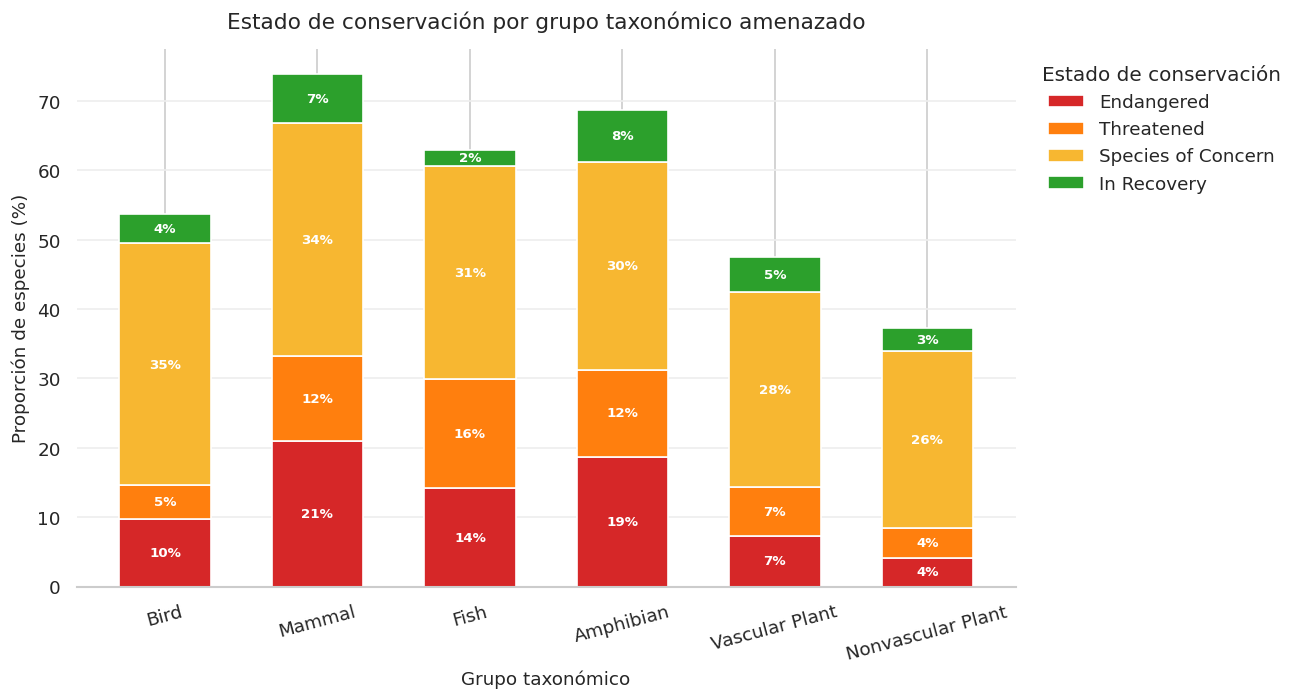

In [5]:
# Reordenamos las filas del DataFrame
orden = ['Bird', 'Mammal', 'Fish', 'Amphibian', 'Vascular Plant', 'Nonvascular Plant']
pivot_pct_amenazada = pivot_pct_amenazada.reindex(orden)

fig, ax = plt.subplots(figsize=(11, 6))  # crea la figura y el área del gráfico

bottom = np.zeros(len(pivot_pct_amenazada))  # posición inicial (base) de cada barra apilada
taxones = pivot_pct_amenazada.index.tolist()  # nombres de los grupos taxonómicos

for status in pivot_pct_amenazada.columns:  # recorre cada estado de conservación

    valores = pivot_pct_amenazada[status].values  # porcentajes para ese estado

    bars = ax.bar(
        taxones,  # categorías en el eje X
        valores,  # altura de cada segmento
        bottom=bottom,  # apila el segmento sobre los anteriores
        color=COLORES_STATUS.get(status, "#cccccc"),  # color asociado al estado
        label=status,  # etiqueta para la leyenda
        width=0.6  # ancho de las barras
    )

    # Etiquetas dentro de la barra solo si el segmento es visible
    for i, (v, b) in enumerate(zip(valores, bottom)):
        # i = posición de la barra, v = valor del segmento, b = base del segmento

        if v > 1:  # muestra etiqueta solo si el segmento es suficientemente grande
            ax.text(
                i,
                b + v / 2,  # coloca el texto en el centro del segmento
                f"{v:.0f}%",
                ha="center", va="center",  # centra horizontal y verticalmente
                fontsize=8,
                color="white",
                fontweight="bold"
            )

    bottom += valores  # actualiza la base para apilar el siguiente estado


ax.set_ylabel("Proporción de especies (%)", fontsize=11)  # etiqueta eje Y
ax.set_xlabel("Grupo taxonómico", fontsize=11)  # etiqueta eje X

ax.set_title(
    "Estado de conservación por grupo taxonómico amenazado",
    fontsize=13,
    pad=12
)  # título del gráfico

ax.tick_params(axis="x", rotation=15)  # rota ligeramente las etiquetas del eje X

# Leyenda fuera del área del gráfico
ax.legend(
    title="Estado de conservación",  # título de la leyenda
    bbox_to_anchor=(1.01, 1),  # posición fuera del gráfico
    loc="upper left",
    frameon=False  # elimina el borde de la leyenda
)

# Eliminamos bordes innecesarios
ax.spines["top"].set_visible(False)  # oculta borde superior
ax.spines["right"].set_visible(False)  # oculta borde derecho
ax.spines["left"].set_visible(False)  # oculta borde izquierdo

ax.yaxis.grid(True, color="#eeeeee", zorder=0)  # añade líneas guía horizontales
ax.set_axisbelow(True)  # coloca la cuadrícula detrás de las barras

plt.tight_layout()  # ajusta espacios automáticamente
plt.savefig("viz01_barras_100pct.png", dpi=150, bbox_inches="tight")  # guarda la figura
plt.show()  # muestra el gráfico

### Interpretación — Viz 01

Responde las siguientes preguntas mirando el gráfico:

- **¿Qué grupo taxonómico tiene la mayor proporción de especies Endangered?**
- **¿Hay algún grupo donde In Recovery sea visible? ¿Qué indica eso?**
- **Decisión de conservación sugerida:** *[escribe aquí tu recomendación basada en el gráfico]*


---
## Viz 02 — Heatmap parque × taxón (Seaborn)
**Pregunta:** ¿Qué parques actúan como refugios importantes para cada taxón?

Un parque con muchas especies amenazadas de reptiles pero pocas de mamíferos
necesita estrategias de conservación diferentes.
El heatmap permite ver esos patrones de un vistazo.

### Preparación de datos


In [8]:
# Filtramos solo las especies amenazadas (excluimos No Concern)
df_amenazadas = df[df["conservation_status"] != "No Concern"].copy()

# Conteo de especies únicas amenazadas por parque y taxón
pivot_heatmap = (
    df_amenazadas
    .groupby(["park_short", "category"])["scientific_name"]
    .nunique()
    .unstack(fill_value=0)
)

# Eliminamos la columna de plantas vasculares si existe en la tabla
pivot_heatmap = pivot_heatmap.drop(columns=["Vascular Plant"])

print("Tabla para el heatmap (especies amenazadas únicas):")
pivot_heatmap


Tabla para el heatmap (especies amenazadas únicas):


category,Amphibian,Bird,Fish,Mammal,Nonvascular Plant,Reptile
park_short,,,,,,
Bryce Canyon,13,103,25,66,32,25
Great Smoky Mts.,55,238,80,121,112,29
Yellowstone,21,193,56,108,58,10
Yosemite,42,262,74,131,119,35


### Construcción del gráfico

Usamos `annot=True` para mostrar los conteos exactos sin perder
la visión global que da el color.


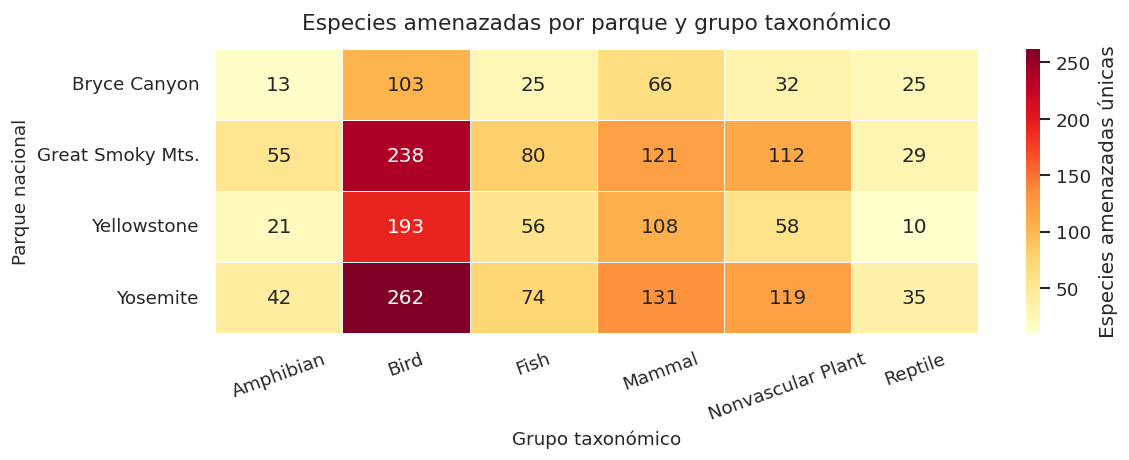

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))  # crea la figura y el área donde se dibujará el heatmap

sns.heatmap(
    pivot_heatmap,  # matriz de datos a visualizar
    annot=True,  # muestra el valor numérico dentro de cada celda
    fmt="d",  # formatea las anotaciones como enteros
    cmap="YlOrRd",  # paleta de colores (amarillo → naranja → rojo)
    linewidths=0.5,  # grosor de las líneas entre celdas
    linecolor="white",  # color de las líneas divisorias
    cbar_kws={"label": "Especies amenazadas únicas"},  # etiqueta de la barra de color
    ax=ax  # dibuja el heatmap en este eje
)

ax.set_title(
    "Especies amenazadas por parque y grupo taxonómico",
    fontsize=13,
    pad=12
)  # título del gráfico

ax.set_xlabel("Grupo taxonómico", fontsize=11)  # etiqueta eje X
ax.set_ylabel("Parque nacional", fontsize=11)  # etiqueta eje Y

ax.tick_params(axis="x", rotation=20)  # rota las etiquetas del eje X
ax.tick_params(axis="y", rotation=0)  # mantiene horizontales las etiquetas del eje Y

plt.tight_layout()  # ajusta espacios para evitar solapamientos

plt.savefig(
    "viz02_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)  # guarda la figura en un archivo PNG

plt.show()  # muestra el gráfico


### Interpretación — Viz 02

- **¿Qué parque concentra más especies amenazadas en total?**
- **¿Hay algún taxón que esté amenazado en un solo parque pero no en los demás?**
  *¿Qué implica eso para la estrategia de ese parque?*
- **¿Qué combinación parque-taxón tiene la celda más oscura?**
  *¿Debería ser una prioridad de intervención?*
- **Decisión de conservación sugerida:** *[escribe aquí]*


---
## Viz 03 — Treemap interactivo (Plotly)
**Pregunta:** ¿Cuál es el volumen real de especies en cada categoría de riesgo?

Las barras del Viz 01 muestran proporciones relativas.
El treemap muestra cantidades absolutas con estructura jerárquica:
cada rectángulo grande es una categoría de conservación,
dividido en bloques más pequeños por taxón.
El hover da el número exacto de especies.

### Preparación de datos


In [10]:
# Conteo de especies únicas por estado de conservación y taxón
treemap_data = (
    species
    .groupby(["conservation_status", "category"])["scientific_name"]
    .nunique()
    .reset_index(name="n_especies")
)

# Excluimos No Concern para que el gráfico se enfoque en las amenazadas
treemap_data = treemap_data[treemap_data["conservation_status"] != "No Concern"]

print(f"Registros para el treemap: {len(treemap_data)}")
treemap_data


Registros para el treemap: 28


,conservation_status,category,n_especies
0,Endangered,Amphibian,15
1,Endangered,Bird,51
2,Endangered,Fish,18
3,Endangered,Mammal,42
4,Endangered,Nonvascular Plant,14
5,Endangered,Reptile,9
6,Endangered,Vascular Plant,327
7,In Recovery,Amphibian,6
8,In Recovery,Bird,22
9,In Recovery,Fish,3


In [11]:
fig = px.treemap(
    treemap_data,  # datos agregados para el treemap
    path=["conservation_status", "category"],  # jerarquía: estado → categoría
    values="n_especies",  # tamaño de los rectángulos
    color="conservation_status",  # color según estado de conservación
    color_discrete_map={  # colores personalizados
        "Endangered":         "#d62728",
        "Threatened":         "#ff7f0e",
        "Species of Concern": "#f7b731",
        "In Recovery":        "#2ca02c"
    },
    hover_data={"n_especies": True},  # mostrar número de especies al pasar el cursor
    labels={"n_especies": "Especies únicas"},  # etiqueta más descriptiva
    title="Volumen de especies amenazadas por categoría de riesgo y taxón"  # título
)

fig.update_traces(
    texttemplate="<b>%{label}</b><br>%{value} especies",  # texto dentro de los rectángulos
    hovertemplate=(  # formato del tooltip
        "<b>%{label}</b><br>"
        "Especies únicas: %{value}<br>"
        "<extra></extra>"
    ),
    textfont_size=12  # tamaño del texto
)

fig.update_layout(
    font=dict(size=11),  # tamaño general de fuente
    margin=dict(t=50, l=10, r=10, b=10)  # márgenes del gráfico
)

fig.show()  # mostrar treemap interactivo

### Interpretación — Viz 03

- **¿Cuál es la categoría de riesgo con más especies en términos absolutos?**
  *¿Coincide con lo que sugerían las proporciones del Viz 01?*
- **Dentro de Species of Concern, ¿qué taxón ocupa más espacio?**
- **¿Qué categoría tiene el área más pequeña? ¿Qué significa eso?**
- **Interacción:** haz click en una categoría para hacer zoom en sus taxones.
- **Decisión de conservación sugerida:** *[escribe aquí]*


---
## Viz 04 — Bubble Plot por parque (Plotly)
**Pregunta:** ¿Existe relación entre el esfuerzo de observación y la carga de conservación?

Un parque con pocas observaciones pero muchas especies amenazadas
puede señalar una necesidad urgente de monitoreo adicional.
Este gráfico combina tres dimensiones en una sola vista:
- Eje X: total de observaciones (proxy del esfuerzo de monitoreo)
- Eje Y: número de especies amenazadas
- Tamaño de burbuja: número de especies únicas totales

### Preparación de datos


In [12]:
# Resumen por parque
bubble_data = (
    df.groupby(["park_name", "park_short"])  # agrupa los registros por parque
    .agg(
        total_observaciones=("observations", "sum"),  # suma todas las observaciones registradas
        n_especies_total=("scientific_name", "nunique"),  # cuenta especies únicas
        n_amenazadas=(
            "conservation_status",
            lambda x: (x != "No Concern").sum()  # cuenta especies con algún estado de conservación ("For each park, count how many rows have a conservation status different from 'No Concern'")
        )
    )
    .reset_index()  # convierte los grupos en columnas normales
)

bubble_data["pct_amenazada"] = (
    bubble_data["n_amenazadas"] / bubble_data["n_especies_total"] * 100
).round(1)  # calcula el porcentaje de especies amenazadas por parque

print(
    bubble_data[
        [
            "park_short",
            "total_observaciones",
            "n_especies_total",
            "n_amenazadas",
            "pct_amenazada"
        ]
    ]
)  # muestra las métricas principales por parque

         park_short  total_observaciones  n_especies_total  n_amenazadas  \
0      Bryce Canyon               298835              2647          1032   
1  Great Smoky Mts.               380954              4459          2754   
2       Yellowstone              1043049              3587          1852   
3          Yosemite               911625              5050          3065   

   pct_amenazada  
0           39.0  
1           61.8  
2           51.6  
3           60.7  


In [ ]:
fig = px.scatter(
    bubble_data,  # DataFrame con las métricas resumidas por parque

    x="total_observaciones",  # eje X: total de observaciones registradas
    y="n_amenazadas",  # eje Y: número de especies amenazadas

    size="n_especies_total",  # tamaño de la burbuja según el número de especies únicas
    size_max=60,  # tamaño máximo de las burbujas

    color="park_short",  # color distinto para cada parque

    hover_name="park_name",  # nombre principal mostrado en el tooltip

    hover_data={  # información adicional al pasar el cursor
        "total_observaciones": True,
        "n_especies_total": True,
        "n_amenazadas": True,
        "pct_amenazada": True,
        "park_short": False
    },

    labels={  # etiquetas más descriptivas para ejes y tooltips
        "total_observaciones": "Total de observaciones (esfuerzo de monitoreo)",
        "n_amenazadas": "Especies amenazadas (CR + EN + VU + IoC)",
        "n_especies_total": "Total de especies únicas",
        "pct_amenazada": "% amenazadas",
        "park_short": "Parque"
    },

    color_discrete_sequence=["#e45756", "#4c78a8", "#72b7b2", "#54a24b"],
    # colores asignados a las burbujas

    title=(
        "Esfuerzo de observación vs. carga de conservación por parque<br>"
        "<sup>Tamaño de burbuja = total de especies únicas registradas</sup>"
    )  # título y subtítulo del gráfico
)

# Anotamos cada burbuja con el nombre corto del parque
for _, row in bubble_data.iterrows():  # recorre cada fila del DataFrame

    fig.add_annotation(
        x=row["total_observaciones"],  # posición horizontal de la etiqueta
        y=row["n_amenazadas"],  # posición vertical de la etiqueta

        text=row["park_short"],  # texto mostrado sobre la burbuja

        showarrow=False,  # no mostrar flecha
        yshift=28,  # desplaza la etiqueta hacia arriba

        font=dict(size=10, color="#333333")  # formato del texto
    )

fig.update_layout(
    plot_bgcolor="white",  # color de fondo del área del gráfico
    paper_bgcolor="white",  # color de fondo de la figura completa

    font=dict(size=11),  # tamaño general de la fuente

    showlegend=False,  # oculta la leyenda (las etiquetas ya identifican los parques)

    xaxis=dict(
        showgrid=True,
        gridcolor="#eeeeee",
        zeroline=False
    ),  # configuración del eje X

    yaxis=dict(
        showgrid=True,
        gridcolor="#eeeeee",
        zeroline=False
    )  # configuración del eje Y
)

fig.show()  # muestra el gráfico interactivo

### Interpretación — Viz 04

- **¿Qué parque tiene más especies amenazadas pero menos observaciones?**
  *¿Sugiere eso una necesidad de mayor monitoreo?*
- **¿Existe una relación positiva entre observaciones y especies amenazadas,
  o los parques más monitoreados tienen menos amenazas?**
- **¿El tamaño de las burbujas (total de especies) correlaciona con las amenazas?**
- **Decisión de conservación sugerida:** *[escribe aquí]*


### Comparativa de Librerías de Visualización en Python

Para elegir la librería correcta, debes equilibrar tres factores: **facilidad de uso**, **estética** e **interactividad**.

| Librería | Estilo de Gráficos | ¿Cuándo usarla? (Su fuerte) | ¿Cuándo evitarla? |
| :--- | :--- | :--- | :--- |
| **Matplotlib** | Estático y tradicional | Cuando necesitas **control total** píxel por píxel, gráficos personalizados complejos o para publicaciones científicas impresas. | Cuando buscas gráficos interactivos modernos rápidamente o diseños estéticos sin configurar mucho código. |
| **Seaborn** | Estático, moderno y profesional | Cuando trabajas con **análisis de datos estadísticos** (Data Science) y quieres gráficos hermosos y complejos (como mapas de calor) con muy pocas líneas de código. | Cuando necesitas que el usuario pueda hacer zoom, pasar el cursor para ver datos (tooltips) o interactuar con el gráfico. |
| **Plotly** | Totalmente interactivo y dinámico | Cuando creas **dashboards, páginas web o reportes de negocios** donde el usuario necesita explorar los datos pasando el cursor, ocultando variables o haciendo zoom. | Cuando vas a generar miles de gráficos en un bucle (puede saturar la memoria) o si solo necesitas un vistazo rápido y estático de los datos. |

---

### Resumen de decisión:
* Usa **Matplotlib** si necesitas "dibujar" algo muy específico desde cero.
* Usa **Seaborn** si quieres que tus datos estadísticos se vean profesionales al instante.
* Usa **Plotly** si tu prioridad número uno es que el gráfico sea interactivo.

---
## Checklist de cierre — Sesión 2

Antes de terminar, verifica que completaste lo siguiente:

- [ ] Viz 01: barras apiladas al 100% con paleta semáforo y etiquetas internas
- [ ] Viz 02: heatmap con conteos exactos y paleta `YlOrRd`
- [ ] Viz 03: treemap interactivo con zoom por categoría funcionando
- [ ] Viz 04: bubble plot con anotaciones y hover detallado
- [ ] Todas las celdas de interpretación completadas con al menos una decisión sugerida

**Próxima sesión:** Viz 05 con Altair (strip plot + box plot),
narrativa de datos completa y resumen ejecutivo.
